CONFIG Y GENERACIÓN DE DATASET

In [1]:
import pandas as pd
import numpy as np
from random import choices
import matplotlib.pyplot as plt

np.random.seed(42)
N = 10000
TARIFA_KWH=0.75

fechas = pd.date_range(
    start="2026-01-01",
    end="2026-12-31",
    freq="D"
)

paises = [
    "Perú",
    "Colombia",
    "México"
]

prob_paises = [
    0.25,
    0.30,
    0.45
]

localidades = {

    "Perú":[
        "Lima",
        "Arequipa",
        "Cusco",
        "Piura",
        "Puno"
    ],

    "Colombia":[
        "Bogotá",
        "Medellín",
        "Cali",
        "Barranquilla",
        "Bucaramanga"
    ],

    "México":[
        "Ciudad de México",
        "Guadalajara",
        "Monterrey",
        "Mérida",
        "Tijuana"
    ]
}

temperaturas = {

    "Lima": {
        1:27,
        2:28,
        3:27,
        4:25,
        5:22,
        6:20,
        7:18,
        8:18,
        9:19,
        10:21,
        11:23,
        12:25
    },

    "Arequipa": {
        1:17,
        2:17,
        3:17,
        4:16,
        5:15,
        6:14,
        7:13,
        8:14,
        9:15,
        10:16,
        11:17,
        12:17
    },

    "Cusco": {
        1:14,
        2:14,
        3:14,
        4:13,
        5:12,
        6:11,
        7:10,
        8:11,
        9:12,
        10:13,
        11:14,
        12:14
    },

    "Piura": {
        1:28,
        2:29,
        3:29,
        4:28,
        5:26,
        6:24,
        7:23,
        8:23,
        9:24,
        10:25,
        11:27,
        12:28
    },

    "Puno": {
        1:12,
        2:12,
        3:12,
        4:11,
        5:10,
        6:8,
        7:8,
        8:9,
        9:10,
        10:11,
        11:12,
        12:12
    },


    "Bogotá": {
        1:14,
        2:14,
        3:14,
        4:14,
        5:14,
        6:13,
        7:13,
        8:13,
        9:13,
        10:14,
        11:14,
        12:14
    },

    "Medellín": {
        1:22,
        2:22,
        3:22,
        4:22,
        5:22,
        6:21,
        7:21,
        8:21,
        9:21,
        10:22,
        11:22,
        12:22
    },

    "Cali": {
        1:24,
        2:24,
        3:24,
        4:24,
        5:24,
        6:23,
        7:23,
        8:23,
        9:23,
        10:24,
        11:24,
        12:24
    },

    "Barranquilla": {
        1:28,
        2:28,
        3:29,
        4:29,
        5:29,
        6:29,
        7:29,
        8:29,
        9:29,
        10:29,
        11:29,
        12:28
    },

    "Bucaramanga": {
        1:23,
        2:23,
        3:23,
        4:23,
        5:23,
        6:22,
        7:22,
        8:22,
        9:22,
        10:23,
        11:23,
        12:23
    },


    "Ciudad de México": {
        1:13,
        2:14,
        3:16,
        4:18,
        5:19,
        6:19,
        7:18,
        8:18,
        9:18,
        10:17,
        11:15,
        12:14
    },

    "Guadalajara": {
        1:19,
        2:20,
        3:22,
        4:24,
        5:26,
        6:25,
        7:24,
        8:24,
        9:24,
        10:23,
        11:21,
        12:19
    },

    "Monterrey": {
        1:15,
        2:18,
        3:22,
        4:26,
        5:29,
        6:31,
        7:32,
        8:31,
        9:29,
        10:25,
        11:20,
        12:16
    },

    "Mérida": {
        1:24,
        2:25,
        3:27,
        4:29,
        5:30,
        6:31,
        7:31,
        8:31,
        9:30,
        10:29,
        11:27,
        12:25
    },

    "Tijuana": {
        1:14,
        2:15,
        3:16,
        4:17,
        5:19,
        6:21,
        7:23,
        8:24,
        9:23,
        10:21,
        11:18,
        12:15
    }

}

tipos_inmueble = [
    "Casa",
    "Departamento",
    "Local"
]

prob_tipo = [
    0.55,
    0.30,
    0.15
]


frecuencias = [
    "Baja",
    "Media",
    "Alta"
]


prob_frecuencia = [
    0.25,
    0.45,
    0.30
]

prob_horario_pico = {
    "Casa":0.70,
    "Departamento":0.60,
    "Local":0.85
}

def generar_habitantes(tipo):
    if tipo=="Casa":
        return np.random.choice([1,2,3,4,5,6,7,8,10],p=[0.05,0.10,0.15,0.20,0.20,0.15,0.08,0.05,0.02])
    elif tipo=="Departamento":
        return np.random.choice([1,2,3,4,5,6,8],p=[0.15,0.30,0.30,0.15,0.06,0.03,0.01])
    else:
        return np.random.choice([1,2,3,5,8,10,15,20],p=[0.05,0.10,0.15,0.20,0.20,0.15,0.10,0.05])

def generar_equipos(tipo):
    if tipo=="Casa":
        return round(np.random.triangular(4,10,25))
    elif tipo=="Departamento":
        return round(np.random.triangular(3,7,15))
    else:
        return round(np.random.triangular(8,15,35))

def generar_horas_consumo(frecuencia):
    if frecuencia=="Baja":
        return np.random.randint(1,7)
    elif frecuencia=="Media":
        return np.random.randint(4,11)
    else:
        return np.random.randint(8,16)




CREACION DE 10000 REGISTROS

In [2]:
datos = []


for i in range(N):

    # Fecha de registro
    fecha = pd.Timestamp(np.random.choice(fechas))

    # País
    pais = np.random.choice(paises,p=prob_paises)

    # Localidad según país
    localidad = np.random.choice(
        localidades[pais]
    )


    # Temperatura según localidad y mes
    temperatura = temperaturas[localidad][fecha.month]

    temperatura = round(temperatura + np.random.uniform(-1,1),1)


    # Tipo de inmueble
    tipo = np.random.choice(
        tipos_inmueble,
        p=prob_tipo)


    # Variables relacionadas al inmueble

    habitantes = generar_habitantes(tipo)
    equipos = generar_equipos(tipo)


    # Frecuencia de uso
    frecuencia = np.random.choice(
        frecuencias,
        p=prob_frecuencia)


    # Horas de alto consumo
    horas_alto_consumo = generar_horas_consumo(
        frecuencia)


    # Uso horario pico

    uso_horario_pico = np.random.choice(
        [True, False],
        p=[prob_horario_pico[tipo],1 - prob_horario_pico[tipo]])


    # CALCULO DEL CONSUMO MENSUAL kWh

    # Consumo base según inmueble

    if tipo == "Casa":
        consumo_base = np.random.triangular(120,220,350)


    elif tipo == "Departamento":
        consumo_base = np.random.triangular(80,160,280)

    else:

        consumo_base = np.random.triangular(200,400,700)

    # Factor habitantes
    factor_habitantes = 1 + ((habitantes - 2) * 0.05)

    if factor_habitantes < 0.85:
        factor_habitantes = 0.85



    # Factor cantidad de equipos
    factor_equipos = 1 + ((equipos - 5) * 0.03)



    # Factor frecuencia
    if frecuencia == "Baja":
        factor_frecuencia = 0.85

    elif frecuencia == "Media":
        factor_frecuencia = 1

    else:
        factor_frecuencia = 1.20



    # Factor horas de alto consumo
    factor_horas = 1 + ((horas_alto_consumo - 5) * 0.03)


    # Factor temperatura
    if temperatura >= 28:
      factor_temperatura = 1.15

    else:
      factor_temperatura = 1



    # Variación natural del consumo
    variacion = np.random.uniform(0.90,1.05)


    consumo_kwh = (
        consumo_base
        *
        factor_habitantes
        *
        factor_equipos
        *
        factor_frecuencia
        *
        factor_horas
        *
        factor_temperatura
        *
        variacion)

    consumo_kwh = round(consumo_kwh,2)


    # CLASIFICACIÓN ENERGÉTICA

    if consumo_kwh < 250:
        categoria = "Eficiente"

    elif consumo_kwh < 450:
        categoria = "Moderado"

    else:
        categoria = "Ineficiente"

    # COSTO ESTIMADO

    costo_estimado = round(consumo_kwh * TARIFA_KWH,2)


    # Guardar registro
    datos.append([

        fecha,
        pais,
        localidad,
        temperatura,
        tipo,
        habitantes,
        equipos,
        frecuencia,
        horas_alto_consumo,
        uso_horario_pico,
        consumo_kwh,
        categoria,
        costo_estimado])


df = pd.DataFrame(
    datos,columns=["fecha_registro",
                   "pais",
                   "localidad",
                   "temperatura_ambiente",
                    "tipo_inmueble",
                    "numero_habitantes",
                    "cantidad_equipos",
                    "frecuencia_uso",
                    "horas_alto_consumo",
                    "uso_horario_pico",
                    "consumo_kwh",
                    "categoria",
                    "costo_estimado"
    ]
)

In [3]:
df.head()

,fecha_registro,pais,localidad,temperatura_ambiente,tipo_inmueble,numero_habitantes,cantidad_equipos,frecuencia_uso,horas_alto_consumo,uso_horario_pico,consumo_kwh,categoria,costo_estimado
0,2026-04-13,México,Monterrey,26.6,Departamento,2,5,Media,8,False,193.23,Eficiente,144.92
1,2026-09-15,México,Guadalajara,23.4,Casa,4,13,Media,4,True,259.09,Moderado,194.32
2,2026-07-07,Colombia,Cali,22.8,Local,5,26,Media,4,True,1163.51,Ineficiente,872.63
3,2026-08-30,Colombia,Medellín,20.2,Departamento,2,5,Media,10,True,169.67,Eficiente,127.25
4,2026-01-02,Colombia,Medellín,22.1,Casa,6,12,Media,7,True,424.04,Moderado,318.03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha_registro        10000 non-null  datetime64[ns]
 1   pais                  10000 non-null  object        
 2   localidad             10000 non-null  object        
 3   temperatura_ambiente  10000 non-null  float64       
 4   tipo_inmueble         10000 non-null  object        
 5   numero_habitantes     10000 non-null  int64         
 6   cantidad_equipos      10000 non-null  int64         
 7   frecuencia_uso        10000 non-null  object        
 8   horas_alto_consumo    10000 non-null  int64         
 9   uso_horario_pico      10000 non-null  bool          
 10  consumo_kwh           10000 non-null  float64       
 11  categoria             10000 non-null  object        
 12  costo_estimado        10000 non-null  float64       
dtypes: bool(1), datet

In [5]:
df.describe()

,fecha_registro,temperatura_ambiente,numero_habitantes,cantidad_equipos,horas_alto_consumo,consumo_kwh,costo_estimado
count,10000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,2026-07-02 07:45:33.120000,20.999750,4.478700,12.538000,7.44980,395.221959,296.416471
min,2026-01-01 00:00:00,7.000000,1.000000,3.000000,1.00000,67.200000,50.400000
25%,2026-04-03 00:00:00,15.800000,3.000000,8.000000,5.00000,226.165000,169.627500
50%,2026-07-03 00:00:00,21.900000,4.000000,11.000000,7.00000,312.375000,234.280000
75%,2026-09-30 00:00:00,24.900000,6.000000,16.000000,10.00000,458.520000,343.895000
max,2026-12-31 00:00:00,33.000000,20.000000,35.000000,15.00000,2462.010000,1846.510000
std,NaN,5.881152,2.925406,5.509845,3.57292,277.736110,208.302057


In [6]:
df.isnull().sum()

,0
fecha_registro,0
pais,0
localidad,0
temperatura_ambiente,0
tipo_inmueble,0
numero_habitantes,0
cantidad_equipos,0
frecuencia_uso,0
horas_alto_consumo,0
uso_horario_pico,0


Todos los atributos presentan 0 valores nulos

In [7]:
df.duplicated().sum()

np.int64(0)

Todos los atributos presentan 0 valores duplicados

## Identificando errores en el dataset creado

In [8]:
df.describe()

,fecha_registro,temperatura_ambiente,numero_habitantes,cantidad_equipos,horas_alto_consumo,consumo_kwh,costo_estimado
count,10000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,2026-07-02 07:45:33.120000,20.999750,4.478700,12.538000,7.44980,395.221959,296.416471
min,2026-01-01 00:00:00,7.000000,1.000000,3.000000,1.00000,67.200000,50.400000
25%,2026-04-03 00:00:00,15.800000,3.000000,8.000000,5.00000,226.165000,169.627500
50%,2026-07-03 00:00:00,21.900000,4.000000,11.000000,7.00000,312.375000,234.280000
75%,2026-09-30 00:00:00,24.900000,6.000000,16.000000,10.00000,458.520000,343.895000
max,2026-12-31 00:00:00,33.000000,20.000000,35.000000,15.00000,2462.010000,1846.510000
std,NaN,5.881152,2.925406,5.509845,3.57292,277.736110,208.302057


El dataset contiene 10 000 registros con variables numéricas que presentan rangos coherentes con las reglas de negocio definidas. La temperatura ambiente varía entre 7 °C y 33 °C, representando las diferentes condiciones climáticas de Perú, Colombia y México. El consumo mensual oscila entre 67.20 kWh y 2462.01 kWh, donde los valores más altos corresponden a escenarios de alto consumo que serán analizados posteriormente para verificar su consistencia.

In [9]:
df[df["numero_habitantes"] == 20]

,fecha_registro,pais,localidad,temperatura_ambiente,tipo_inmueble,numero_habitantes,cantidad_equipos,frecuencia_uso,horas_alto_consumo,uso_horario_pico,consumo_kwh,categoria,costo_estimado
347,2026-05-02,México,Tijuana,18.9,Local,20,18,Alta,13,True,1694.46,Ineficiente,1270.84
492,2026-08-07,Colombia,Bucaramanga,21.8,Local,20,25,Baja,6,True,933.81,Ineficiente,700.36
551,2026-08-20,Perú,Arequipa,13.4,Local,20,17,Alta,9,True,1985.25,Ineficiente,1488.94
615,2026-10-08,México,Mérida,29.0,Local,20,14,Alta,9,True,1213.44,Ineficiente,910.08
900,2026-11-13,Colombia,Medellín,21.1,Local,20,11,Media,7,True,905.68,Ineficiente,679.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9229,2026-08-28,Colombia,Barranquilla,28.4,Local,20,16,Baja,1,True,797.71,Ineficiente,598.28
9438,2026-03-28,México,Tijuana,16.9,Local,20,17,Media,10,True,1257.86,Ineficiente,943.40
9582,2026-11-23,Colombia,Barranquilla,29.4,Local,20,18,Media,7,True,1384.30,Ineficiente,1038.22
9669,2026-06-12,Colombia,Bogotá,12.6,Local,20,21,Media,6,True,1112.76,Ineficiente,834.57


Se verificaron los registros con el número máximo de habitantes (20 personas) para validar que correspondieran a establecimientos comerciales. Se comprobó que todos los casos pertenecen al tipo de inmueble Local, por lo que no existen inconsistencias como viviendas con un número poco realista de habitantes. Esto confirma que las reglas utilizadas para la simulación fueron aplicadas correctamente.

In [10]:
df.nlargest(10,"consumo_kwh")

,fecha_registro,pais,localidad,temperatura_ambiente,tipo_inmueble,numero_habitantes,cantidad_equipos,frecuencia_uso,horas_alto_consumo,uso_horario_pico,consumo_kwh,categoria,costo_estimado
3946,2026-06-28,México,Mérida,30.8,Local,20,22,Alta,10,True,2462.01,Ineficiente,1846.51
4394,2026-03-19,Colombia,Barranquilla,28.4,Local,10,28,Alta,8,True,2389.04,Ineficiente,1791.78
4046,2026-03-14,Perú,Cusco,14.4,Local,15,25,Alta,13,True,2360.94,Ineficiente,1770.70
4097,2026-09-20,México,Ciudad de México,17.1,Local,20,25,Alta,12,True,2219.51,Ineficiente,1664.63
2719,2026-09-05,México,Tijuana,23.8,Local,15,25,Alta,10,True,2196.75,Ineficiente,1647.56
4107,2026-09-13,Colombia,Barranquilla,29.5,Local,3,30,Alta,14,True,2180.11,Ineficiente,1635.08
3148,2026-09-15,Perú,Piura,23.4,Local,20,25,Alta,13,True,2128.40,Ineficiente,1596.30
1049,2026-10-15,Colombia,Barranquilla,28.8,Local,15,23,Alta,8,True,2123.44,Ineficiente,1592.58
8934,2026-05-14,México,Mérida,31.0,Local,10,24,Alta,11,True,2116.84,Ineficiente,1587.63
6494,2026-01-23,Colombia,Bogotá,14.6,Local,20,29,Alta,14,True,2099.38,Ineficiente,1574.54


Los registros con mayor consumo energético corresponden principalmente a locales comerciales con una alta cantidad de equipos, frecuencia de uso alta y un elevado número de horas de consumo. Estos valores representan escenarios extremos, pero coherentes, por lo que se consideran outliers válidos y no errores en los datos.

In [11]:
df["categoria"].value_counts()

,count
categoria,
Moderado,4185
Eficiente,3229
Ineficiente,2586


La distribución de las categorías energéticas presenta una proporción adecuada entre las tres clases (Eficiente, Moderado e Ineficiente). Esto reduce el riesgo de desbalance de clases durante el entrenamiento de los modelos de clasificación y favorece un aprendizaje más representativo.

In [12]:
df.to_csv(
    "consumo_energia.csv",
    index=False
)

Una vez verificada la consistencia de los datos generados, se exporta el dataset a formato CSV para facilitar su reutilización durante el análisis exploratorio, el entrenamiento del modelo y la integración con los demás módulos del proyecto.

## EDA (Exploratory Data Analysis)

In [13]:
df.head()

,fecha_registro,pais,localidad,temperatura_ambiente,tipo_inmueble,numero_habitantes,cantidad_equipos,frecuencia_uso,horas_alto_consumo,uso_horario_pico,consumo_kwh,categoria,costo_estimado
0,2026-04-13,México,Monterrey,26.6,Departamento,2,5,Media,8,False,193.23,Eficiente,144.92
1,2026-09-15,México,Guadalajara,23.4,Casa,4,13,Media,4,True,259.09,Moderado,194.32
2,2026-07-07,Colombia,Cali,22.8,Local,5,26,Media,4,True,1163.51,Ineficiente,872.63
3,2026-08-30,Colombia,Medellín,20.2,Departamento,2,5,Media,10,True,169.67,Eficiente,127.25
4,2026-01-02,Colombia,Medellín,22.1,Casa,6,12,Media,7,True,424.04,Moderado,318.03


Se visualizan los primeros registros del conjunto de datos para verificar que las variables fueron generadas correctamente y presentan el formato esperado.

In [14]:
df.shape

(10000, 13)

El conjunto de datos está compuesto por 10 000 registros y 13 variables, las cuales contienen información relacionada con el consumo energético, características del inmueble y variables ambientales.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha_registro        10000 non-null  datetime64[ns]
 1   pais                  10000 non-null  object        
 2   localidad             10000 non-null  object        
 3   temperatura_ambiente  10000 non-null  float64       
 4   tipo_inmueble         10000 non-null  object        
 5   numero_habitantes     10000 non-null  int64         
 6   cantidad_equipos      10000 non-null  int64         
 7   frecuencia_uso        10000 non-null  object        
 8   horas_alto_consumo    10000 non-null  int64         
 9   uso_horario_pico      10000 non-null  bool          
 10  consumo_kwh           10000 non-null  float64       
 11  categoria             10000 non-null  object        
 12  costo_estimado        10000 non-null  float64       
dtypes: bool(1), datet

Se verifican los tipos de datos de cada variable y la existencia de valores nulos. Todas las columnas presentan el tipo de dato esperado y no se identifican registros faltantes.

In [16]:
df["pais"].value_counts()

,count
pais,
México,4525
Colombia,3036
Perú,2439


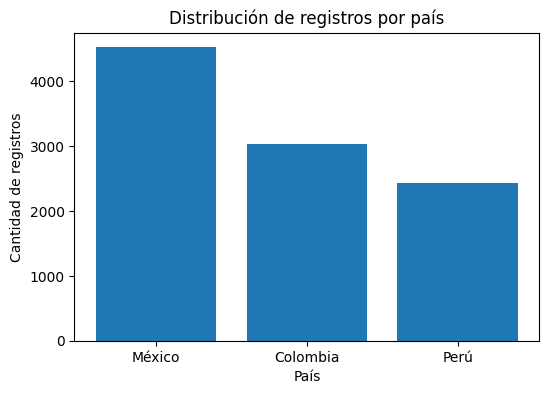

In [17]:
import matplotlib.pyplot as plt

conteo_paises = df["pais"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(conteo_paises.index, conteo_paises.values)

plt.title("Distribución de registros por país")
plt.xlabel("País")
plt.ylabel("Cantidad de registros")

plt.show()

In [18]:
(df["pais"].value_counts(normalize=True) * 100).round(2)

,proportion
pais,
México,45.25
Colombia,30.36
Perú,24.39


El gráfico muestra que México concentra la mayor cantidad de registros, seguido de Colombia y Perú. Esta distribución permite analizar el consumo energético considerando diferentes contextos geográficos y climáticos, aportando diversidad al conjunto de datos.

In [19]:
df["localidad"].value_counts()

,count
localidad,
Ciudad de México,940
Mérida,913
Tijuana,912
Guadalajara,882
Monterrey,878
Medellín,635
Barranquilla,611
Bogotá,606
Bucaramanga,606


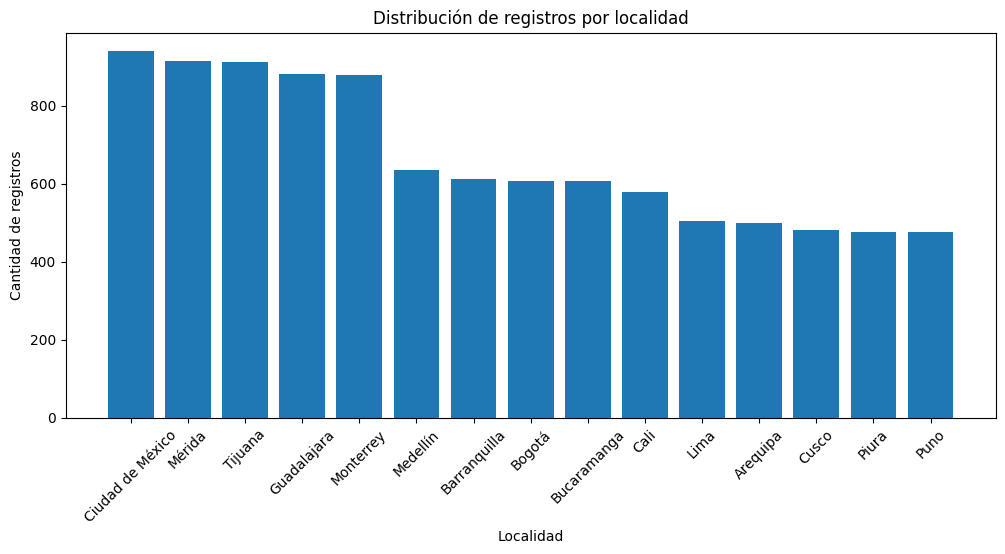

In [20]:
import matplotlib.pyplot as plt

conteo_localidad = df["localidad"].value_counts()

plt.figure(figsize=(12,5))

plt.bar(
    conteo_localidad.index,
    conteo_localidad.values
)

plt.title("Distribución de registros por localidad")
plt.xlabel("Localidad")
plt.ylabel("Cantidad de registros")

plt.xticks(rotation=45)

plt.show()

Se aprecia una distribución equilibrada entre las localidades pertenecientes a un mismo país. Asimismo, las ciudades mexicanas presentan un mayor número de registros debido a que México concentra la mayor participación dentro del conjunto de datos.

In [21]:
(df["tipo_inmueble"].value_counts(normalize=True) * 100).round(2)

,proportion
tipo_inmueble,
Casa,54.07
Departamento,30.38
Local,15.55


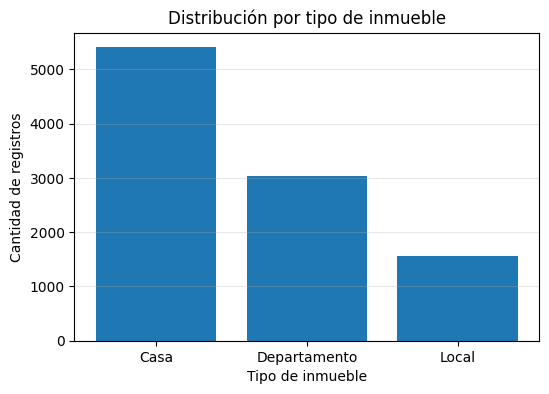

In [22]:
conteo_tipo = df["tipo_inmueble"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    conteo_tipo.index,
    conteo_tipo.values
)

plt.title("Distribución por tipo de inmueble")
plt.xlabel("Tipo de inmueble")
plt.ylabel("Cantidad de registros")

plt.grid(axis="y", alpha=0.3)

plt.show()

Se observa que las viviendas tipo Casa representan la mayor proporción del conjunto de datos, seguidas por los Departamentos y los Locales. Esta distribución indica que el dataset está compuesto principalmente por inmuebles residenciales, mientras que los establecimientos comerciales constituyen una menor proporción de los registros analizados.

In [23]:
(df["categoria"].value_counts(normalize=True) * 100).round(2)

,proportion
categoria,
Moderado,41.85
Eficiente,32.29
Ineficiente,25.86


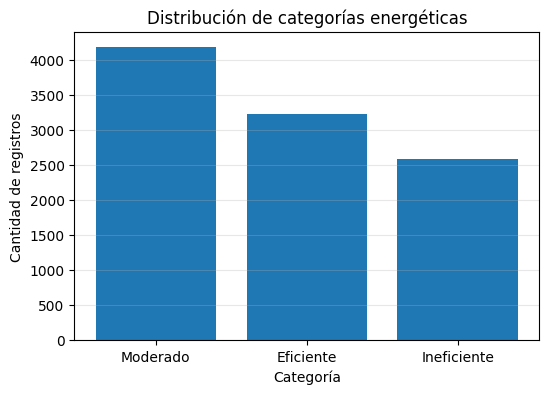

In [24]:
conteo_categoria = df["categoria"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    conteo_categoria.index,
    conteo_categoria.values
)

plt.title("Distribución de categorías energéticas")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de registros")

plt.grid(axis="y", alpha=0.3)

plt.show()

Se observa que la categoría Moderado concentra la mayor cantidad de registros, seguida por Eficiente e Ineficiente. La distribución es relativamente equilibrada entre las tres clases, lo que favorece el entrenamiento de modelos de clasificación al contar con una representación adecuada de cada perfil de consumo energético.

In [25]:
consumo_tipo = df.groupby("tipo_inmueble")["consumo_kwh"].mean().sort_values(ascending=False)

consumo_tipo

,consumo_kwh
tipo_inmueble,
Local,877.573910
Casa,355.752547
Departamento,218.577400


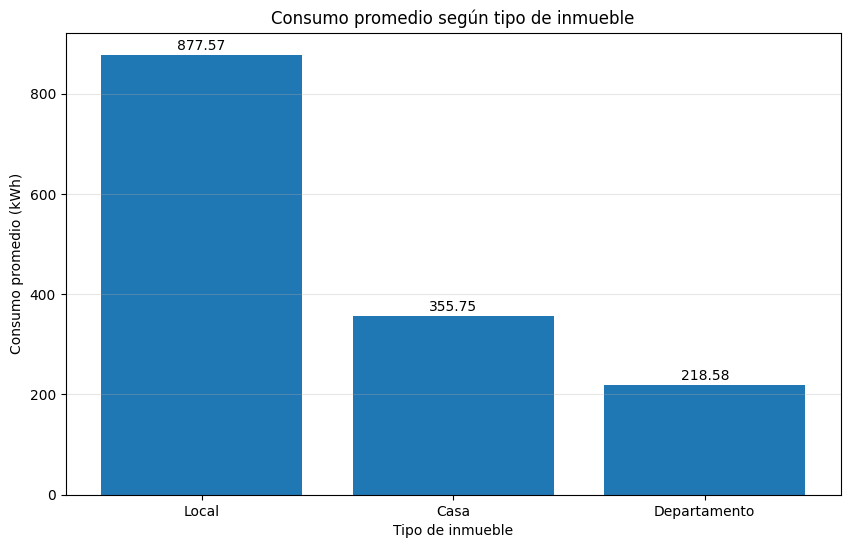

In [26]:
plt.figure(figsize=(10,6))

barras = plt.bar(
    consumo_tipo.index,
    consumo_tipo.values
)

plt.title("Consumo promedio según tipo de inmueble")
plt.xlabel("Tipo de inmueble")
plt.ylabel("Consumo promedio (kWh)")

# Mostrar el valor encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 10,
        f"{altura:.2f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

Los locales comerciales registran el mayor consumo promedio de energía (877.57 kWh/mes), muy por encima de las casas (355.75 kWh/mes) y los departamentos (218.58 kWh/mes). Este comportamiento evidencia que el tipo de inmueble influye significativamente en el consumo energético, ya que los establecimientos comerciales suelen operar durante más horas y disponer de una mayor cantidad de equipos eléctricos.

In [27]:
consumo_frecuencia = (
    df.groupby("frecuencia_uso")["consumo_kwh"]
    .mean()
    .sort_values(ascending=False)
)

consumo_frecuencia

,consumo_kwh
frecuencia_uso,
Alta,514.599667
Media,379.122837
Baja,284.333960


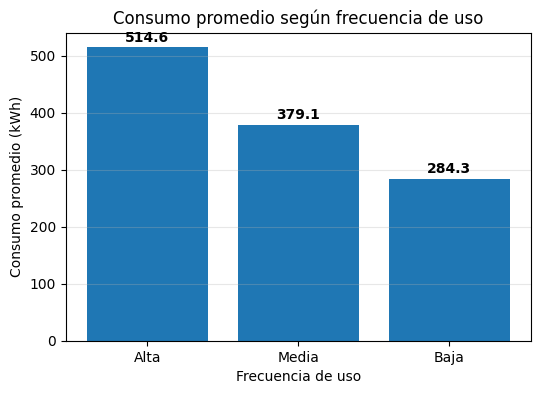

In [28]:
plt.figure(figsize=(6,4))

barras = plt.bar(
    consumo_frecuencia.index,
    consumo_frecuencia.values
)

plt.title("Consumo promedio según frecuencia de uso")
plt.xlabel("Frecuencia de uso")
plt.ylabel("Consumo promedio (kWh)")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 10,
        f"{altura:.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

Se observa una relación directa entre la frecuencia de uso y el consumo energético mensual. Los inmuebles con una frecuencia de uso alta presentan el mayor consumo promedio (514.60 kWh/mes), seguidos por aquellos con frecuencia media (379.12 kWh/mes) y baja (284.33 kWh/mes). Este comportamiento indica que una mayor utilización de los equipos eléctricos está asociada a un incremento en la demanda energética.

In [29]:
consumo_pais = (
    df.groupby("pais")["consumo_kwh"]
    .mean()
    .sort_values(ascending=False)
)

consumo_pais

,consumo_kwh
pais,
Colombia,400.500418
México,395.276181
Perú,388.550882


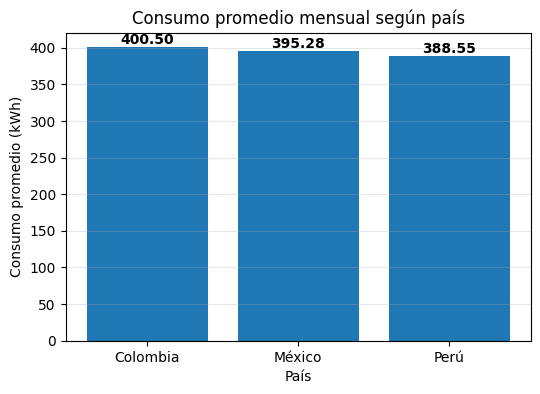

In [30]:
plt.figure(figsize=(6,4))

barras = plt.bar(
    consumo_pais.index,
    consumo_pais.values
)

plt.title("Consumo promedio mensual según país")
plt.xlabel("País")
plt.ylabel("Consumo promedio (kWh)")

# Valores encima de cada barra
for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 5,
        f"{altura:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

El consumo promedio mensual presenta valores similares entre los países analizados. Colombia registra el mayor consumo promedio con 400.50 kWh/mes, seguido por México con 395.28 kWh/mes y Perú con 388.55 kWh/mes. La diferencia entre países es reducida, lo que indica que la ubicación geográfica por sí sola no determina el consumo energético, sino que este depende principalmente de factores como el tipo de inmueble, cantidad de equipos, frecuencia de uso y hábitos de consumo.

In [31]:
consumo_total_localidad = (
    df.groupby("localidad")["consumo_kwh"]
    .sum()
    .sort_values(ascending=False)
)

consumo_total_localidad

,consumo_kwh
localidad,
Mérida,386279.08
Monterrey,358925.39
Ciudad de México,353524.66
Guadalajara,345976.68
Tijuana,343918.91
Barranquilla,282084.51
Medellín,250355.08
Bogotá,231236.34
Bucaramanga,230871.92


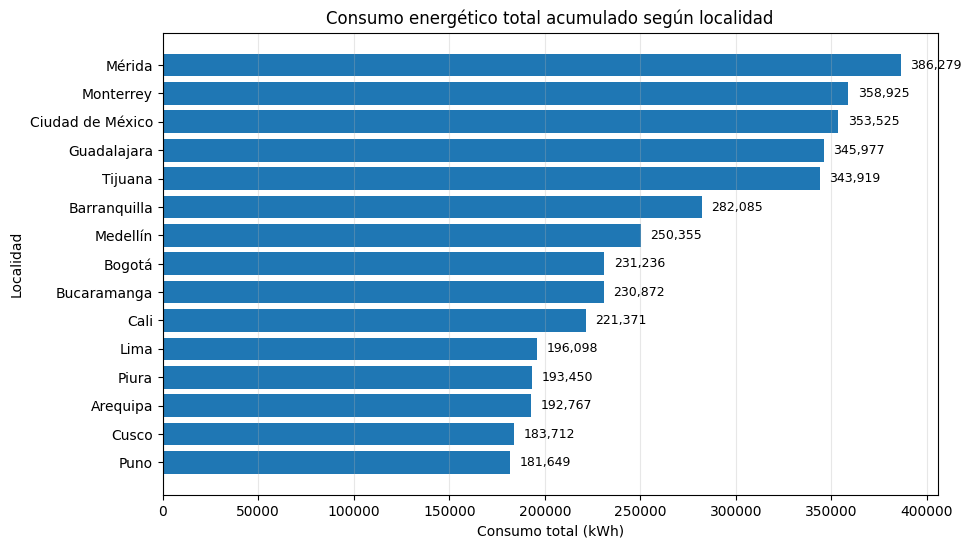

In [32]:
plt.figure(figsize=(10,6))

barras = plt.barh(
    consumo_total_localidad.index,
    consumo_total_localidad.values
)

plt.title("Consumo energético total acumulado según localidad")
plt.xlabel("Consumo total (kWh)")
plt.ylabel("Localidad")

# Invertir orden del eje Y
plt.gca().invert_yaxis()

# Valores en las barras
for barra in barras:
    ancho = barra.get_width()

    plt.text(
        ancho + 5000,
        barra.get_y() + barra.get_height()/2,
        f"{ancho:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.show()

El consumo energético total acumulado presenta diferencias importantes entre las localidades analizadas. Mérida concentra el mayor consumo con 386,279.08 kWh, seguida de Monterrey con 358,925.39 kWh y Ciudad de México con 353,524.66 kWh. Por otro lado, Puno registra el menor consumo acumulado con 181,648.56 kWh.

## CORRELACION CANTIDAD DE EQUIPOS Y CONSUMO ENERGETICO

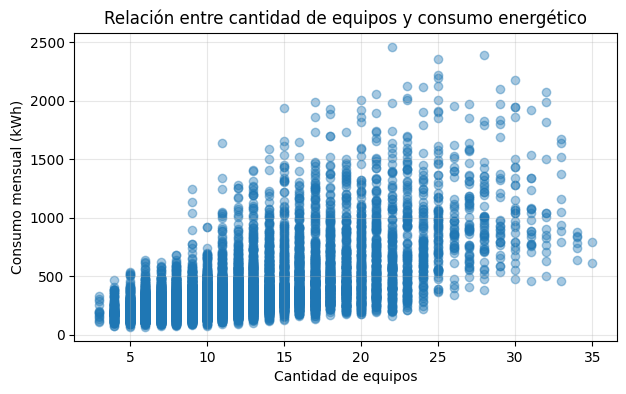

In [33]:
plt.figure(figsize=(7,4))

plt.scatter(
    df["cantidad_equipos"],
    df["consumo_kwh"],
    alpha=0.4
)

plt.title("Relación entre cantidad de equipos y consumo energético")
plt.xlabel("Cantidad de equipos")
plt.ylabel("Consumo mensual (kWh)")

plt.grid(alpha=0.3)

plt.show()

In [34]:
correlacion_equipos = df["cantidad_equipos"].corr(df["consumo_kwh"])

print("Correlación cantidad de equipos vs consumo:", correlacion_equipos)

Correlación cantidad de equipos vs consumo: 0.6149809057939047


Se observa una relación positiva moderada entre la cantidad de equipos y el consumo energético, respaldada por un coeficiente de correlación de 0.615. Esto indica que, en general, a medida que aumenta la cantidad de equipos en un inmueble, también tiende a incrementarse el consumo mensual de energía. No obstante, la dispersión de los datos evidencia que existen otros factores que también influyen en el consumo, por lo que la cantidad de equipos no es la única variable explicativa.

CORRELACION NUMERO DE HABITANTES Y CONSUMO ENERGETICO

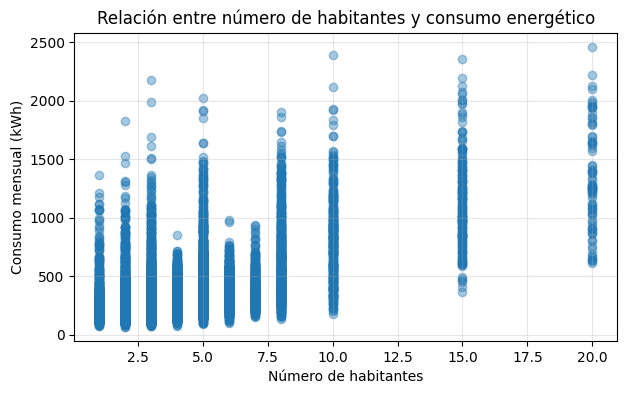

In [35]:
plt.figure(figsize=(7,4))

plt.scatter(
    df["numero_habitantes"],
    df["consumo_kwh"],
    alpha=0.4
)

plt.title("Relación entre número de habitantes y consumo energético")
plt.xlabel("Número de habitantes")
plt.ylabel("Consumo mensual (kWh)")

plt.grid(alpha=0.3)

plt.show()

In [36]:
correlacion_habitantes = df["numero_habitantes"].corr(df["consumo_kwh"])

print("Correlación número de habitantes vs consumo:", correlacion_habitantes)

Correlación número de habitantes vs consumo: 0.5824876841228638


Se observa una relación positiva moderada entre el número de habitantes y el consumo energético, respaldada por un coeficiente de correlación de 0.582. El gráfico evidencia que, conforme aumenta el número de habitantes, el consumo energético tiende a incrementarse. Sin embargo, la dispersión de los datos indica que inmuebles con una misma cantidad de habitantes pueden presentar consumos diferentes, lo que sugiere que el consumo también depende de otros factores, como la cantidad de equipos, las horas de alto consumo y la temperatura ambiente.

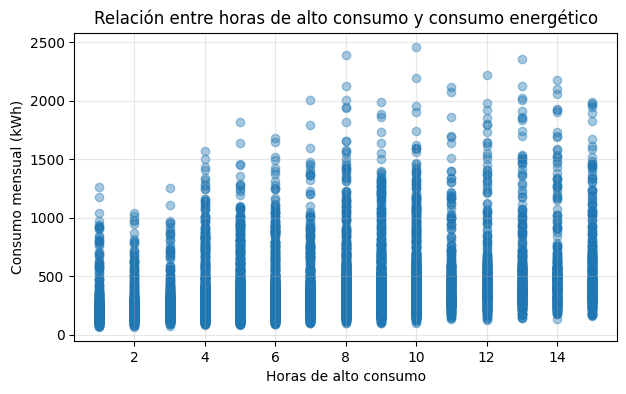

In [37]:
plt.figure(figsize=(7,4))

plt.scatter(
    df["horas_alto_consumo"],
    df["consumo_kwh"],
    alpha=0.4
)

plt.title("Relación entre horas de alto consumo y consumo energético")
plt.xlabel("Horas de alto consumo")
plt.ylabel("Consumo mensual (kWh)")

plt.grid(alpha=0.3)

plt.show()

In [38]:
correlacion_horas = df["horas_alto_consumo"].corr(df["consumo_kwh"])

print("Correlación horas de alto consumo vs consumo:", correlacion_horas)

Correlación horas de alto consumo vs consumo: 0.30891645824907454


Se observa una relación positiva débil entre las horas de alto consumo y el consumo energético, evidenciada por un coeficiente de correlación de 0.309. Aunque el gráfico muestra una ligera tendencia ascendente, la dispersión de los datos indica que el número de horas de alto consumo no explica por sí solo las variaciones en el consumo energético. Esto sugiere que el consumo depende de la interacción de múltiples variables, como la cantidad de equipos, el número de habitantes y otras características del inmueble.

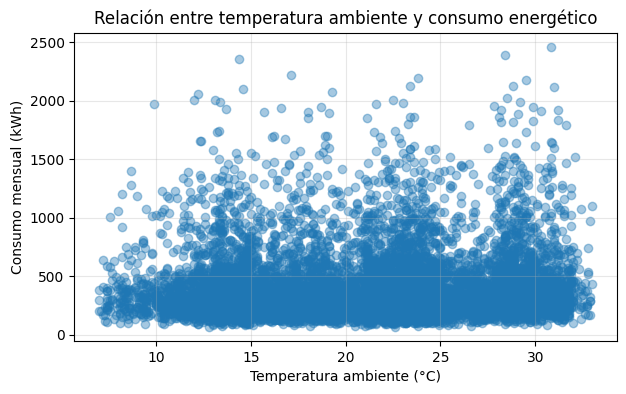

In [39]:
plt.figure(figsize=(7,4))

plt.scatter(
    df["temperatura_ambiente"],
    df["consumo_kwh"],
    alpha=0.4
)

plt.title("Relación entre temperatura ambiente y consumo energético")
plt.xlabel("Temperatura ambiente (°C)")
plt.ylabel("Consumo mensual (kWh)")

plt.grid(alpha=0.3)

plt.show()

In [40]:
correlacion_temperatura = df["temperatura_ambiente"].corr(df["consumo_kwh"])

print("Correlación temperatura vs consumo:", correlacion_temperatura)

Correlación temperatura vs consumo: 0.07081742292482407


Se observa una relación positiva muy débil entre la temperatura ambiente y el consumo energético, con un coeficiente de correlación de 0.071. La dispersión de los datos evidencia que la temperatura, por sí sola, no presenta una influencia significativa sobre el consumo energético en el conjunto de datos analizado. Esto sugiere que otras variables, como la cantidad de equipos y el número de habitantes, tienen un mayor impacto en el comportamiento del consumo.

In [41]:
corr = df[
    [
        "consumo_kwh",
        "cantidad_equipos",
        "numero_habitantes",
        "horas_alto_consumo",
        "temperatura_ambiente"
    ]
].corr()

corr

,consumo_kwh,cantidad_equipos,numero_habitantes,horas_alto_consumo,temperatura_ambiente
consumo_kwh,1.000000,0.614981,0.582488,0.308916,0.070817
cantidad_equipos,0.614981,1.000000,0.328534,0.019549,0.029780
numero_habitantes,0.582488,0.328534,1.000000,-0.002710,0.008787
horas_alto_consumo,0.308916,0.019549,-0.002710,1.000000,0.010793
temperatura_ambiente,0.070817,0.029780,0.008787,0.010793,1.000000


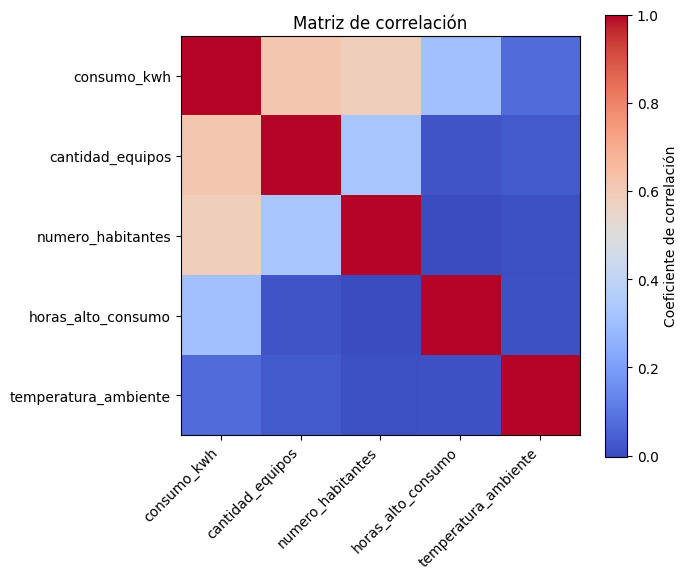

In [42]:
plt.figure(figsize=(7,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Coeficiente de correlación")

plt.title("Matriz de correlación")

plt.tight_layout()

plt.show()

La matriz de correlación evidencia que la cantidad de equipos (0.615) y el número de habitantes (0.582) presentan las relaciones positivas más fuertes con el consumo energético, lo que indica que estas variables tienen una mayor influencia en el comportamiento del consumo. Por otro lado, las horas de alto consumo muestran una correlación positiva débil (0.309), mientras que la temperatura ambiente presenta una relación prácticamente nula (0.071).


## Procesamiento

Se generarán dos opciones para el cálculo de categorías, con el fin de explorar qué tipo de división resulta más beneficiosa para el caso.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import json

### Opcion 1: Indice compuesto por inmueble

Se generan nuevas variables para hacer el analisis:



*   Consumo por habitante: Este se normaliza dentro de cada tipo de inmueble, para comparar tipos de inmuebles entre ellos.
*   Proporcion horas alto consumo
*   Uso hora pico: 0 o 1

Teniendo en cuenta la correlacion observada previamente en el EDA, equipos/habitantes son las variables mas correlacionadas con consumo. Por este motivo el puntaje compuesto se distribuye con mayor peso en estas variables.


```
score = 0.5 * consumo_por_habitante_norm + 0.3 * proporcion_horas_alto + 0.2 * uso_horario_pico
```

Adicionalmente los umbrales de las categorias se definieron usando percentiles 33% y 66%.


In [44]:

df["consumo_por_habitante"] = df["consumo_kwh"] / df["numero_habitantes"]
df["proporcion_horas_alto"] = df["horas_alto_consumo"] / 24
df["pico_int"] = df["uso_horario_pico"].astype(int)

# Normalización dentro de cada tipo de inmueble
df["consumo_por_habitante_norm"] = df.groupby("tipo_inmueble")["consumo_por_habitante"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Puntaje compuesto
df["Puntaje_compuesto"] = (
    0.5 * df["consumo_por_habitante_norm"]
    + 0.3 * df["proporcion_horas_alto"]
    + 0.2 * df["pico_int"]
)

# Percentiles
p33, p66 = df["Puntaje_compuesto"].quantile([0.33, 0.66])

def clasificar_por_score(score):
    if score < p33:
        return "Eficiente"
    elif score < p66:
        return "Moderado"
    else:
        return "Ineficiente"

# Drop de la categoría anterior y reemplazo por la nueva
df = df.drop(columns=["categoria"])
df["categoria_indice"] = df["Puntaje_compuesto"].apply(clasificar_por_score)

df["categoria_indice"].value_counts()

,count
categoria_indice,
Ineficiente,3400
Moderado,3300
Eficiente,3300


### Opción 2: Agrupacion no supervisada


In [45]:
# Variables por agrupar previamente definidas.
caracteristicas_grupo = df[["consumo_por_habitante", "cantidad_equipos",
                        "proporcion_horas_alto", "pico_int"]]

# Aplicar z-score a cada columna elegida para estandarizar columnas
escalador = StandardScaler()
caracteristicas_escaladas= escalador.fit_transform(caracteristicas_grupo)
# Encontrar 3 grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["grupo"] = kmeans.fit_predict(caracteristicas_escaladas)
# Ordenar cada grupo
orden_clusters = (
    df.groupby("grupo")["consumo_por_habitante"]
    .mean()
    .sort_values()
    .index.tolist()
)
# etiquetar grupo
mapa_etiquetas = {
    orden_clusters[0]: "Eficiente",
    orden_clusters[1]: "Moderado",
    orden_clusters[2]: "Ineficiente"
}

df["categoria_grupo"] = df["grupo"].map(mapa_etiquetas)
df["categoria_grupo"].value_counts()


,count
categoria_grupo,
Eficiente,5329
Moderado,2902
Ineficiente,1769


### Comparación entre los enfoques


In [46]:
tabla_comparacion = pd.crosstab(df["categoria_indice"], df["categoria_grupo"])
tabla_comparacion

categoria_grupo,Eficiente,Ineficiente,Moderado
categoria_indice,,,
Eficiente,1644,85,1571
Ineficiente,1550,1243,607
Moderado,2135,441,724


In [47]:
coincidencia = (df["categoria_indice"] == df["categoria_grupo"]).mean()
print(f"Coincidencia entre ambos enfoques: {coincidencia:.1%}")


Coincidencia entre ambos enfoques: 36.1%


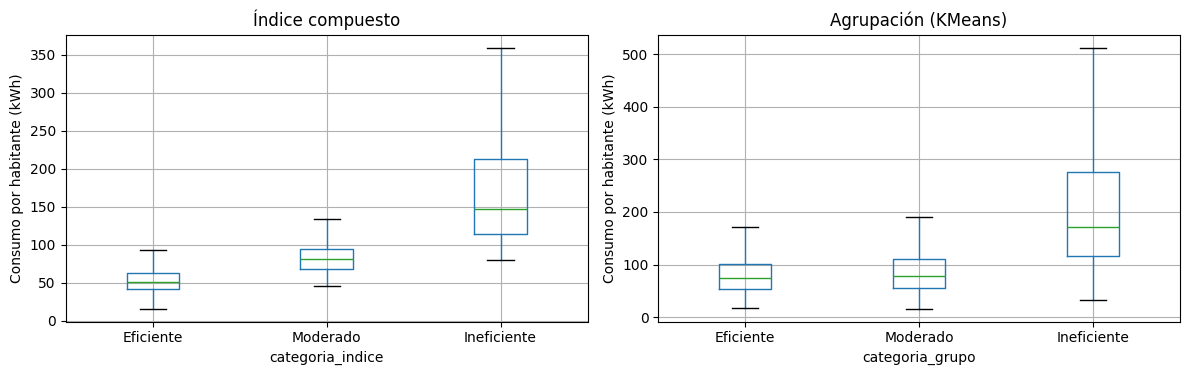

In [48]:
orden = ["Eficiente", "Moderado", "Ineficiente"]
df["categoria_indice"] = pd.Categorical(df["categoria_indice"], categories=orden, ordered=True)
df["categoria_grupo"] = pd.Categorical(df["categoria_grupo"], categories=orden, ordered=True)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df.boxplot(column="consumo_por_habitante", by="categoria_indice",
            ax=axes[0], showfliers=False)
axes[0].set_title("Índice compuesto")
axes[0].set_ylabel("Consumo por habitante (kWh)")

df.boxplot(column="consumo_por_habitante", by="categoria_grupo",
            ax=axes[1], showfliers=False)
axes[1].set_title("Agrupación (KMeans)")
axes[1].set_ylabel("Consumo por habitante (kWh)")

plt.suptitle("")
plt.tight_layout()
plt.show()


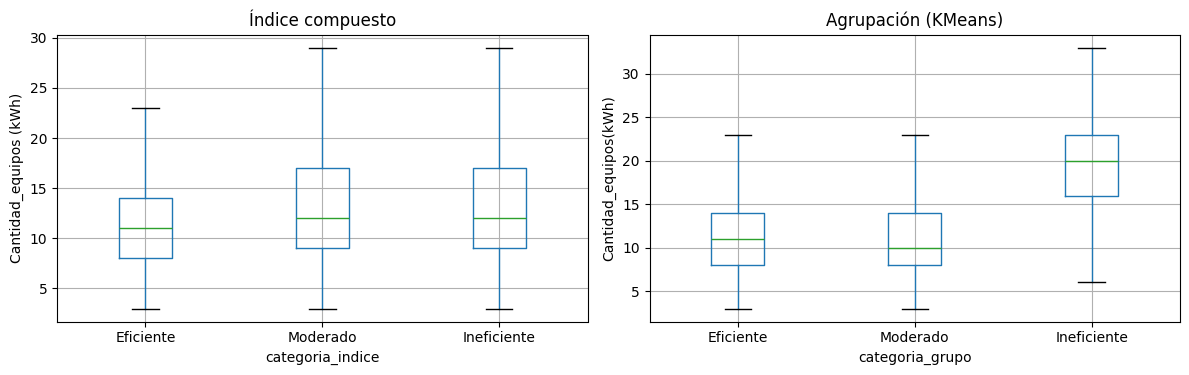

In [49]:
orden = ["Eficiente", "Moderado", "Ineficiente"]
df["categoria_indice"] = pd.Categorical(df["categoria_indice"], categories=orden, ordered=True)
df["categoria_grupo"] = pd.Categorical(df["categoria_grupo"], categories=orden, ordered=True)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df.boxplot(column="cantidad_equipos", by="categoria_indice",
            ax=axes[0], showfliers=False)
axes[0].set_title("Índice compuesto")
axes[0].set_ylabel("Cantidad_equipos (kWh)")

df.boxplot(column="cantidad_equipos", by="categoria_grupo",
            ax=axes[1], showfliers=False)
axes[1].set_title("Agrupación (KMeans)")
axes[1].set_ylabel("Cantidad_equipos(kWh)")

plt.suptitle("")
plt.tight_layout()
plt.show()


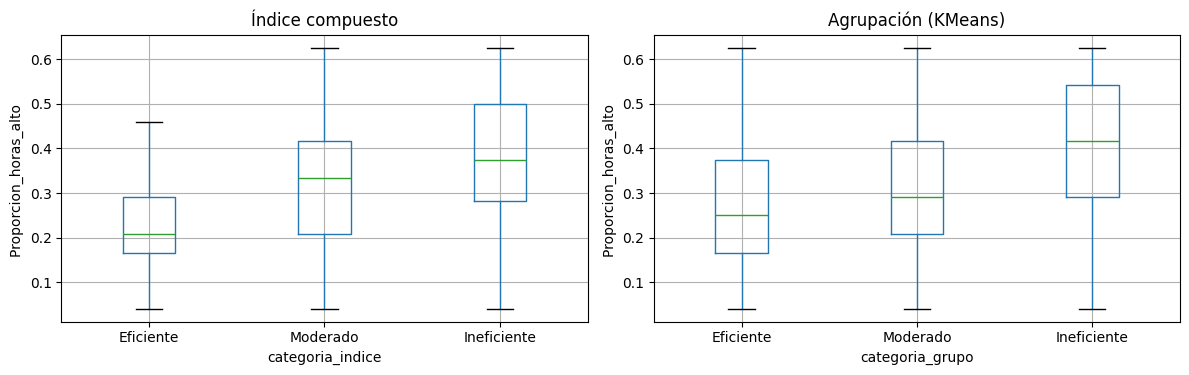

In [50]:
orden = ["Eficiente", "Moderado", "Ineficiente"]
df["categoria_indice"] = pd.Categorical(df["categoria_indice"], categories=orden, ordered=True)
df["categoria_grupo"] = pd.Categorical(df["categoria_grupo"], categories=orden, ordered=True)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df.boxplot(column="proporcion_horas_alto", by="categoria_indice",
            ax=axes[0], showfliers=False)
axes[0].set_title("Índice compuesto")
axes[0].set_ylabel("Proporcion_horas_alto ")

df.boxplot(column="proporcion_horas_alto", by="categoria_grupo",
            ax=axes[1], showfliers=False)
axes[1].set_title("Agrupación (KMeans)")
axes[1].set_ylabel("Proporcion_horas_alto ")

plt.suptitle("")
plt.tight_layout()
plt.show()


Decisión: se usa el **Índice compuesto (Opción 1)** como `categoria` final debido a que es **interpretable** — cada componente del puntaje tiene
un significado de explícito y los pesos están justificados por el EDA.

## Preprocesamiento para el modelo (con la nueva `categoria_indice`)

In [51]:
df_model = df.copy()
df_model["uso_horario_pico"] = df_model["uso_horario_pico"].astype(int)

categorical_cols = ["pais", "localidad", "tipo_inmueble", "frecuencia_uso"]
numeric_cols = ["temperatura_ambiente", "numero_habitantes", "cantidad_equipos",
                 "horas_alto_consumo", "uso_horario_pico", "consumo_kwh"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_encoded = encoder.fit_transform(df_model[categorical_cols])
cat_cols_out = encoder.get_feature_names_out(categorical_cols)
cat_df = pd.DataFrame(cat_encoded, columns=cat_cols_out, index=df_model.index)

X = pd.concat([df_model[numeric_cols], cat_df], axis=1)
y = df_model["categoria_indice"]

FEATURE_COLUMNS = X.columns.tolist()
print("Total de features:", len(FEATURE_COLUMNS))


Total de features: 30


## Train / Test split y entrenamiento

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)
modelo.fit(X_train, y_train)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (8000, 30)  Test: (2000, 30)


## Evaluación del modelo

In [53]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {accuracy:.2%}")
print()
print(classification_report(y_test, y_pred))

Accuracy en test: 88.35%

              precision    recall  f1-score   support

   Eficiente       0.91      0.88      0.89       660
 Ineficiente       0.93      0.93      0.93       680
    Moderado       0.81      0.85      0.83       660

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.89      0.88      0.88      2000



El modelo alcanza una exactitud (accuracy) de 88.35% sobre el conjunto de prueba. Las categorías **Eficiente** e **Ineficiente** presentan un desempeño alto (precision y recall superiores a 0.88), mientras que **Moderado** obtiene un desempeño ligeramente menor (precision 0.81, recall 0.85), lo cual es esperable ya que es la categoría intermedia y limita tanto con Eficiente como con Ineficiente en la escala de puntaje compuesto.

### Matriz de confusión

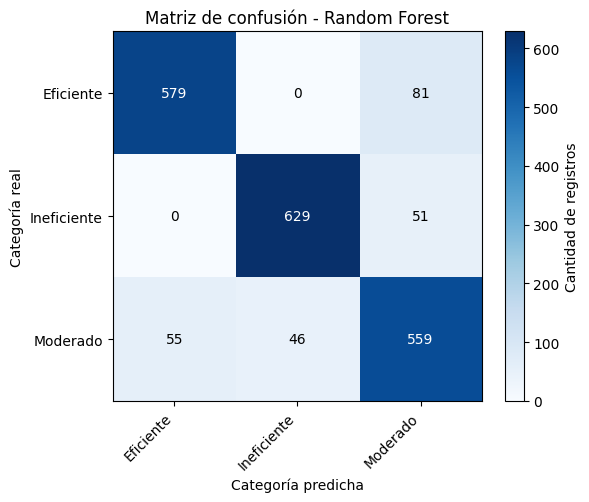

In [54]:
etiquetas = modelo.classes_
matriz_confusion = confusion_matrix(y_test, y_pred, labels=etiquetas)

plt.figure(figsize=(6,5))
plt.imshow(matriz_confusion, cmap="Blues", interpolation="nearest")

plt.xticks(range(len(etiquetas)), etiquetas, rotation=45, ha="right")
plt.yticks(range(len(etiquetas)), etiquetas)

for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        plt.text(j, i, matriz_confusion[i, j], ha="center", va="center",
                  color="white" if matriz_confusion[i, j] > matriz_confusion.max()/2 else "black")

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")
plt.colorbar(label="Cantidad de registros")
plt.tight_layout()
plt.show()

La matriz de confusión confirma que el modelo **nunca confunde Eficiente con Ineficiente** (0 casos en ambas direcciones), lo cual tiene sentido ya que son los extremos opuestos de la escala de consumo. La mayor parte de los errores del modelo ocurre entre **Moderado** y sus categorías vecinas, reflejando que los límites entre percentiles (33% y 66%) generan una zona de transición más difícil de separar.

### Importancia de variables

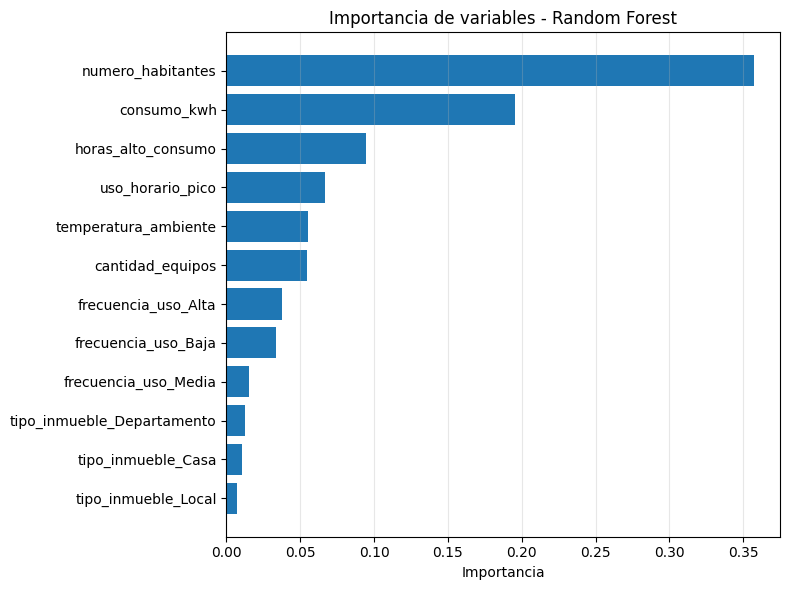

,0
numero_habitantes,0.357093
consumo_kwh,0.195569
horas_alto_consumo,0.094596
uso_horario_pico,0.066785
temperatura_ambiente,0.055273
cantidad_equipos,0.054802
frecuencia_uso_Alta,0.037772
frecuencia_uso_Baja,0.033754
frecuencia_uso_Media,0.015355
tipo_inmueble_Departamento,0.012494


In [55]:
importancias = pd.Series(modelo.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
top_importancias = importancias.head(12)

plt.figure(figsize=(8,6))
plt.barh(top_importancias.index[::-1], top_importancias.values[::-1])
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

top_importancias

Las variables con mayor peso en el modelo son `numero_habitantes` y `consumo_kwh`, seguidas de `horas_alto_consumo` y `uso_horario_pico`. Este resultado es coherente con la definición del `Puntaje_compuesto`: el 50% del puntaje depende del consumo por habitante (que combina `consumo_kwh` y `numero_habitantes`), el 30% de la proporción de horas de alto consumo y el 20% del uso en horario pico. El modelo, entrenado únicamente con las variables originales, logró identificar por sí mismo la misma jerarquía de importancia definida en las reglas de negocio.

## Recomendaciones de ahorro energético

Se define un sistema de recomendaciones de dos niveles:

1. **Recomendaciones base según categoría**: un conjunto de buenas prácticas generales asociado a cada categoría energética (`Eficiente`, `Moderado`, `Ineficiente`).
2. **Recomendaciones puntuales según comportamiento**: reglas adicionales que se activan según variables específicas del inmueble (uso en horario pico, horas de alto consumo elevadas, cantidad de equipos por encima del promedio de su tipo de inmueble).

In [56]:
RECOMENDACIONES_POR_CATEGORIA = {
    "Eficiente": [
        "El inmueble mantiene un consumo eficiente; se recomienda continuar con los hábitos actuales de uso.",
        "Realizar mantenimiento preventivo periódico a los equipos (limpieza de filtros, revisión de instalaciones) para conservar su eficiencia.",
        "Usar temporizadores o enchufes inteligentes para mantener el control del consumo en el tiempo."
    ],
    "Moderado": [
        "Revisar los equipos de mayor consumo y evaluar su reemplazo por versiones de bajo consumo (etiqueta A o tecnología inverter).",
        "Desconectar equipos en modo de espera (standby), ya que consumen energía sin estar en uso activo.",
        "Aprovechar la luz natural y la ventilación para reducir el uso de iluminación y climatización artificial.",
        "Distribuir el uso de electrodomésticos de forma que no coincidan varios equipos de alta potencia al mismo tiempo."
    ],
    "Ineficiente": [
        "Realizar una auditoría energética del inmueble para identificar los equipos con mayor consumo.",
        "Sustituir progresivamente electrodomésticos antiguos por modelos de alta eficiencia energética.",
        "Reducir las horas de uso de equipos de climatización y calentadores eléctricos.",
        "Instalar iluminación LED en todo el inmueble.",
        "Evaluar el aislamiento térmico del inmueble para reducir la necesidad de climatización artificial."
    ]
}

# Cantidad de equipos promedio observada en el dataset, por tipo de inmueble
equipos_promedio_tipo = df.groupby("tipo_inmueble", observed=True)["cantidad_equipos"].mean().to_dict()

def generar_recomendaciones(registro):
    """
    Genera una lista de recomendaciones de ahorro a partir de un registro con, al menos,
    las llaves: categoria, tipo_inmueble, cantidad_equipos, horas_alto_consumo, uso_horario_pico.
    """
    categoria = registro["categoria"]
    recomendaciones = list(RECOMENDACIONES_POR_CATEGORIA.get(categoria, []))

    if registro.get("uso_horario_pico"):
        recomendaciones.append(
            "Se detectó uso en horario pico: trasladar equipos de alto consumo (lavadora, secadora, plancha) "
            "fuera de este horario puede reducir el costo de la factura."
        )

    if registro.get("horas_alto_consumo", 0) >= 10:
        recomendaciones.append(
            "Las horas de alto consumo reportadas son elevadas; limitar el uso simultáneo de equipos de alta "
            "potencia ayuda a reducir el consumo mensual."
        )

    tipo = registro.get("tipo_inmueble")
    promedio_tipo = equipos_promedio_tipo.get(tipo)
    if promedio_tipo is not None and registro.get("cantidad_equipos", 0) > promedio_tipo * 1.3:
        recomendaciones.append(
            f"La cantidad de equipos reportada ({registro['cantidad_equipos']}) supera el promedio observado "
            f"para inmuebles tipo {tipo} ({promedio_tipo:.1f}); se recomienda evaluar cuáles son realmente necesarios."
        )

    return recomendaciones

## Lógica de estimación financiera

Para estimar el ahorro potencial se usa como referencia el **consumo promedio por habitante observado en el dataset para cada categoría** (`benchmark_consumo_habitante`), calculado en el EDA. La lógica es la siguiente:

1. Se calcula el consumo por habitante actual del inmueble.
2. Se compara contra el consumo por habitante promedio de la categoría objetivo (por defecto, `Eficiente`).
3. Si el inmueble ya está en la categoría objetivo o en una mejor, no se proyecta ahorro.
4. En caso contrario, se calcula la diferencia y se traduce a kWh y a costo (usando `TARIFA_KWH`), tanto mensual como anual.

Los valores de costo se expresan en la misma unidad monetaria implícita en `TARIFA_KWH`; como el dataset combina tres países con monedas distintas (Perú, Colombia y México), `TARIFA_KWH` debe ajustarse según el caso real que se quiera evaluar.

In [57]:
benchmark_consumo_habitante = df.groupby("categoria_indice", observed=True)["consumo_por_habitante"].mean().to_dict()
ORDEN_CATEGORIAS = ["Eficiente", "Moderado", "Ineficiente"]

print("Consumo promedio por habitante según categoría (kWh):")
for cat, valor in benchmark_consumo_habitante.items():
    print(f"  {cat}: {valor:.2f}")

def estimar_ahorro(consumo_kwh, numero_habitantes, categoria_actual, categoria_objetivo="Eficiente", tarifa=TARIFA_KWH):
    """
    Estima el ahorro potencial en kWh y en costo al pasar de la categoria_actual a la categoria_objetivo,
    usando como referencia el consumo promedio por habitante observado en el dataset (benchmark_consumo_habitante).
    """
    consumo_habitante_actual = consumo_kwh / numero_habitantes
    consumo_habitante_objetivo = benchmark_consumo_habitante[categoria_objetivo]

    costo_actual_mensual = round(consumo_kwh * tarifa, 2)
    costo_actual_anual = round(costo_actual_mensual * 12, 2)

    ya_en_objetivo = ORDEN_CATEGORIAS.index(categoria_actual) <= ORDEN_CATEGORIAS.index(categoria_objetivo)

    resultado = {
        "categoria_actual": categoria_actual,
        "categoria_objetivo": categoria_objetivo,
        "costo_actual_mensual": costo_actual_mensual,
        "costo_actual_anual": costo_actual_anual,
    }

    if ya_en_objetivo or consumo_habitante_actual <= consumo_habitante_objetivo:
        resultado.update({
            "ahorro_kwh_mensual": 0.0,
            "ahorro_kwh_anual": 0.0,
            "ahorro_monetario_mensual": 0.0,
            "ahorro_monetario_anual": 0.0,
            "porcentaje_reduccion_estimado": 0.0,
            "mensaje": "El inmueble ya se encuentra en la categoría objetivo o en una mejor."
        })
        return resultado

    ahorro_habitante = consumo_habitante_actual - consumo_habitante_objetivo
    ahorro_kwh_mensual = round(ahorro_habitante * numero_habitantes, 2)
    ahorro_kwh_anual = round(ahorro_kwh_mensual * 12, 2)
    ahorro_monetario_mensual = round(ahorro_kwh_mensual * tarifa, 2)
    ahorro_monetario_anual = round(ahorro_monetario_mensual * 12, 2)
    porcentaje_reduccion = round((ahorro_kwh_mensual / consumo_kwh) * 100, 1)

    consumo_proyectado_mensual = round(consumo_kwh - ahorro_kwh_mensual, 2)
    costo_proyectado_mensual = round(consumo_proyectado_mensual * tarifa, 2)
    costo_proyectado_anual = round(costo_proyectado_mensual * 12, 2)

    resultado.update({
        "consumo_proyectado_mensual_kwh": consumo_proyectado_mensual,
        "costo_proyectado_mensual": costo_proyectado_mensual,
        "costo_proyectado_anual": costo_proyectado_anual,
        "ahorro_kwh_mensual": ahorro_kwh_mensual,
        "ahorro_kwh_anual": ahorro_kwh_anual,
        "ahorro_monetario_mensual": ahorro_monetario_mensual,
        "ahorro_monetario_anual": ahorro_monetario_anual,
        "porcentaje_reduccion_estimado": porcentaje_reduccion
    })
    return resultado

Consumo promedio por habitante según categoría (kWh):
  Eficiente: 53.12
  Moderado: 86.69
  Ineficiente: 186.90


## Sistema integrado: predicción + estimación financiera + recomendaciones

La función `evaluar_vivienda` recibe los datos crudos de un inmueble (los mismos campos usados para generar el dataset), aplica el mismo `encoder` entrenado para construir el vector de variables, predice la categoría con el modelo Random Forest y combina el resultado con la estimación financiera y las recomendaciones de ahorro.

In [58]:
def evaluar_vivienda(datos):
    """
    datos: dict con las llaves
        pais, localidad, tipo_inmueble, numero_habitantes, cantidad_equipos,
        frecuencia_uso, horas_alto_consumo, uso_horario_pico, temperatura_ambiente, consumo_kwh
    """
    fila = pd.DataFrame([datos])
    fila["uso_horario_pico"] = fila["uso_horario_pico"].astype(int)

    cat_encoded_fila = encoder.transform(fila[categorical_cols])
    cat_df_fila = pd.DataFrame(cat_encoded_fila, columns=encoder.get_feature_names_out(categorical_cols), index=fila.index)

    X_fila = pd.concat([fila[numeric_cols], cat_df_fila], axis=1)
    X_fila = X_fila.reindex(columns=FEATURE_COLUMNS, fill_value=0)

    categoria_predicha = modelo.predict(X_fila)[0]
    probabilidades = {clase: float(p) for clase, p in zip(modelo.classes_, modelo.predict_proba(X_fila)[0].round(3))}

    financiero = estimar_ahorro(
        consumo_kwh=datos["consumo_kwh"],
        numero_habitantes=datos["numero_habitantes"],
        categoria_actual=categoria_predicha
    )

    registro_para_recomendaciones = dict(datos)
    registro_para_recomendaciones["categoria"] = categoria_predicha
    recomendaciones = generar_recomendaciones(registro_para_recomendaciones)

    return {
        "categoria_predicha": categoria_predicha,
        "probabilidades": probabilidades,
        "estimacion_financiera": financiero,
        "recomendaciones": recomendaciones
    }

### Ejemplo de uso

In [59]:
ejemplo = {
    "pais": "México",
    "localidad": "Monterrey",
    "tipo_inmueble": "Casa",
    "numero_habitantes": 4,
    "cantidad_equipos": 22,
    "frecuencia_uso": "Alta",
    "horas_alto_consumo": 13,
    "uso_horario_pico": True,
    "temperatura_ambiente": 30.5,
    "consumo_kwh": 610.0
}

resultado = evaluar_vivienda(ejemplo)

print("="*60)
print(f"Categoría predicha: {resultado['categoria_predicha']}")
print(f"Probabilidades por clase: {resultado['probabilidades']}")
print("="*60)

fin = resultado["estimacion_financiera"]
print("\nEstimación financiera (objetivo: categoría Eficiente)")
print(f"  Costo actual mensual:        {fin['costo_actual_mensual']}")
print(f"  Costo actual anual:          {fin['costo_actual_anual']}")
if fin["ahorro_kwh_mensual"] > 0:
    print(f"  Consumo proyectado mensual:  {fin['consumo_proyectado_mensual_kwh']} kWh")
    print(f"  Costo proyectado mensual:    {fin['costo_proyectado_mensual']}")
    print(f"  Costo proyectado anual:      {fin['costo_proyectado_anual']}")
    print(f"  Ahorro estimado mensual:     {fin['ahorro_kwh_mensual']} kWh  ({fin['ahorro_monetario_mensual']} en costo)")
    print(f"  Ahorro estimado anual:       {fin['ahorro_kwh_anual']} kWh  ({fin['ahorro_monetario_anual']} en costo)")
    print(f"  Reducción estimada:          {fin['porcentaje_reduccion_estimado']}%")
else:
    print(f"  {fin['mensaje']}")

print("\nRecomendaciones de ahorro:")
for i, rec in enumerate(resultado["recomendaciones"], 1):
    print(f"  {i}. {rec}")

# Ejemplo con una meta intermedia (Moderado) en lugar de pasar directo a Eficiente
fin_intermedio = estimar_ahorro(
    consumo_kwh=ejemplo["consumo_kwh"],
    numero_habitantes=ejemplo["numero_habitantes"],
    categoria_actual=resultado["categoria_predicha"],
    categoria_objetivo="Moderado"
)
print("\nEstimación financiera (meta intermedia: categoría Moderado)")
print(f"  Ahorro estimado mensual: {fin_intermedio['ahorro_kwh_mensual']} kWh  ({fin_intermedio['ahorro_monetario_mensual']} en costo)")
print(f"  Reducción estimada:      {fin_intermedio['porcentaje_reduccion_estimado']}%")

Categoría predicha: Ineficiente
Probabilidades por clase: {'Eficiente': 0.001, 'Ineficiente': 0.94, 'Moderado': 0.059}

Estimación financiera (objetivo: categoría Eficiente)
  Costo actual mensual:        457.5
  Costo actual anual:          5490.0
  Consumo proyectado mensual:  212.5 kWh
  Costo proyectado mensual:    159.38
  Costo proyectado anual:      1912.56
  Ahorro estimado mensual:     397.5 kWh  (298.12 en costo)
  Ahorro estimado anual:       4770.0 kWh  (3577.44 en costo)
  Reducción estimada:          65.2%

Recomendaciones de ahorro:
  1. Realizar una auditoría energética del inmueble para identificar los equipos con mayor consumo.
  2. Sustituir progresivamente electrodomésticos antiguos por modelos de alta eficiencia energética.
  3. Reducir las horas de uso de equipos de climatización y calentadores eléctricos.
  4. Instalar iluminación LED en todo el inmueble.
  5. Evaluar el aislamiento térmico del inmueble para reducir la necesidad de climatización artificial.
  6. 

El ejemplo corresponde a una casa con una cantidad de equipos y horas de alto consumo elevadas, por lo que el modelo la clasifica como **Ineficiente** con alta confianza. La estimación financiera muestra el ahorro potencial tanto para llegar directamente a la categoría **Eficiente** como para una meta intermedia (**Moderado**), lo que permite plantear objetivos de ahorro graduales y más realistas.

## Serialización del modelo

Se guarda un solo objeto (`modelo_bundle`) que agrupa todo lo necesario para reutilizar el pipeline en otro entorno (script, API, aplicación web) sin depender de este notebook: el modelo entrenado, el encoder, las columnas de entrada, la tarifa y los benchmarks usados en la estimación financiera. Se serializa con **joblib** (recomendado para objetos de scikit-learn, ya que maneja de forma más eficiente los arreglos de NumPy) y adicionalmente con **pickle**, por si se necesita en un entorno donde solo esté disponible la librería estándar.

In [60]:
import joblib
import pickle
from datetime import datetime

# Distribución general de categorías
distribucion_categorias = (df["categoria_indice"].value_counts(normalize=True) * 100).round(2).to_dict()

# Distribución de categorías por tipo de inmueble
distribucion_por_tipo = (
    df.groupby("tipo_inmueble")["categoria_indice"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
    .to_dict(orient="index")
)

# Distribución de categorías por país
distribucion_por_pais = (
    df.groupby("pais")["categoria_indice"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
    .to_dict(orient="index")
)

# Distribución de categorías por localidad
distribucion_por_localidad = (
    df.groupby("localidad")["categoria_indice"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
    .to_dict(orient="index")
)

# Benchmark de consumo por habitante, cruzado por tipo de inmueble + categoría
benchmark_por_tipo = (
    df.groupby(["tipo_inmueble", "categoria_indice"])["consumo_por_habitante"]
    .mean()
    .round(2)
    .unstack(fill_value=0)
    .to_dict(orient="index")
)

modelo_bundle = {
    "modelo": modelo,
    "encoder": encoder,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "feature_columns": FEATURE_COLUMNS,
    "clases": list(modelo.classes_),
    "tarifa_kwh": TARIFA_KWH,
    "benchmark_consumo_habitante": benchmark_consumo_habitante,
    "equipos_promedio_tipo": equipos_promedio_tipo,
    "distribucion_categorias": distribucion_categorias,
    "distribucion_por_tipo": distribucion_por_tipo,
    "distribucion_por_pais": distribucion_por_pais,
    "distribucion_por_localidad": distribucion_por_localidad,
    "benchmark_por_tipo": benchmark_por_tipo,
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "version": "1.1"
}

joblib.dump(modelo_bundle, "modelo_energia.joblib")
print("Modelo serializado con joblib -> modelo_energia.joblib")

with open("modelo_energia.pkl", "wb") as f:
    pickle.dump(modelo_bundle, f)
print("Modelo serializado con pickle -> modelo_energia.pkl")


/tmp/ipykernel_1463/4005028912.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["tipo_inmueble", "categoria_indice"])["consumo_por_habitante"]


Modelo serializado con joblib -> modelo_energia.joblib
Modelo serializado con pickle -> modelo_energia.pkl


### Verificación de la serialización

In [61]:
modelo_cargado = joblib.load("modelo_energia.joblib")

pred_original = modelo.predict(X_test.iloc[:5])
pred_cargado = modelo_cargado["modelo"].predict(X_test.iloc[:5])

print("Predicciones con el modelo original: ", list(pred_original))
print("Predicciones con el modelo cargado:  ", list(pred_cargado))
print("¿Las predicciones coinciden?:", bool((pred_original == pred_cargado).all()))

Predicciones con el modelo original:  ['Eficiente', 'Ineficiente', 'Ineficiente', 'Eficiente', 'Eficiente']
Predicciones con el modelo cargado:   ['Eficiente', 'Ineficiente', 'Ineficiente', 'Eficiente', 'Eficiente']
¿Las predicciones coinciden?: True


La recarga del modelo desde disco produce exactamente las mismas predicciones que el modelo original en memoria, lo que confirma que la serialización preserva el comportamiento del pipeline completo.

Para reutilizar el modelo en otro script o notebook basta con cargar el archivo y volver a aplicar la misma lógica de `evaluar_vivienda`:

```python
import joblib

bundle = joblib.load("modelo_energia.joblib")
modelo = bundle["modelo"]
encoder = bundle["encoder"]
categorical_cols = bundle["categorical_cols"]
numeric_cols = bundle["numeric_cols"]
FEATURE_COLUMNS = bundle["feature_columns"]
benchmark_consumo_habitante = bundle["benchmark_consumo_habitante"]
TARIFA_KWH = bundle["tarifa_kwh"]
```

In [64]:
print(modelo_bundle["benchmark_por_tipo"])
print(modelo_bundle["distribucion_por_tipo"])

{np.str_('Casa'): {'Eficiente': 50.13, 'Moderado': 76.82, 'Ineficiente': 157.69}, np.str_('Departamento'): {'Eficiente': 50.33, 'Moderado': 81.46, 'Ineficiente': 157.91}, np.str_('Local'): {'Eficiente': 72.26, 'Moderado': 125.1, 'Ineficiente': 345.69}}
{np.str_('Casa'): {'Eficiente': 31.87, 'Moderado': 34.18, 'Ineficiente': 33.96}, np.str_('Departamento'): {'Eficiente': 37.56, 'Moderado': 28.31, 'Ineficiente': 34.13}, np.str_('Local'): {'Eficiente': 28.04, 'Moderado': 38.07, 'Ineficiente': 33.89}}


In [65]:
print(modelo_bundle["distribucion_categorias"])
print(modelo_bundle["distribucion_por_pais"])
print(modelo_bundle["distribucion_por_localidad"])

{'Ineficiente': 34.0, 'Eficiente': 33.0, 'Moderado': 33.0}
{np.str_('Colombia'): {'Eficiente': 33.76, 'Moderado': 33.7, 'Ineficiente': 32.54}, np.str_('México'): {'Eficiente': 32.22, 'Moderado': 32.4, 'Ineficiente': 35.38}, np.str_('Perú'): {'Eficiente': 33.5, 'Moderado': 33.25, 'Ineficiente': 33.25}}
{np.str_('Arequipa'): {'Eficiente': 36.4, 'Moderado': 31.0, 'Ineficiente': 32.6}, np.str_('Barranquilla'): {'Eficiente': 28.97, 'Moderado': 33.39, 'Ineficiente': 37.64}, np.str_('Bogotá'): {'Eficiente': 36.96, 'Moderado': 31.02, 'Ineficiente': 32.01}, np.str_('Bucaramanga'): {'Eficiente': 32.18, 'Moderado': 37.29, 'Ineficiente': 30.53}, np.str_('Cali'): {'Eficiente': 37.02, 'Moderado': 34.6, 'Ineficiente': 28.37}, np.str_('Ciudad de México'): {'Eficiente': 36.06, 'Moderado': 31.81, 'Ineficiente': 32.13}, np.str_('Cusco'): {'Eficiente': 30.29, 'Moderado': 35.48, 'Ineficiente': 34.23}, np.str_('Guadalajara'): {'Eficiente': 32.99, 'Moderado': 33.9, 'Ineficiente': 33.11}, np.str_('Lima'): {'E